# Class Activity: "Open the DQN Black Box" on CartPole

**Format:** pairs | **Environment:** `rl-gym` conda env | **Duration:** one class session

The DQN used here is *naive*: no replay buffer and no target network (see `rl101-naive-dqn.py`).

## Learning goals
- Map each piece of the DQN to the CartPole problem: state in, Q-values out, TD target, loss.
- Understand the roles of epsilon-greedy exploration, gamma, and the learning rate.
- Observe the instability of naive DQN and motivate the replay buffer and target network.

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')

import random
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.set_num_threads(1)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [2]:
# Default hyperparameters (same as rl101-naive-dqn.py, except NUM_STEPS)
GAMMA = 0.99
LR = 1e-3
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY_STEPS = 20000
NUM_STEPS = 20000
HIDDEN_SIZE = 128


class QNetwork(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def epsilon_at(step, eps_start=EPSILON_START, eps_end=EPSILON_END, decay_steps=EPSILON_DECAY_STEPS):
    return max(eps_end, eps_start - (eps_start - eps_end) * step / decay_steps)


def select_action(q_net, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
        return int(torch.argmax(q_net(state_t), dim=1).item())

In [3]:
def train(num_steps=NUM_STEPS, gamma=GAMMA, lr=LR, eps_start=EPSILON_START, eps_end=EPSILON_END,
          eps_decay_steps=EPSILON_DECAY_STEPS, hidden_size=HIDDEN_SIZE, seed=0, verbose=False):
    """Naive DQN: one update per step, batch size 1, same network for the TD target."""
    set_seed(seed)
    env = gym.make("CartPole-v1")
    obs_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    q_net = QNetwork(obs_dim, n_actions, hidden_size)
    optimizer = optim.Adam(q_net.parameters(), lr=lr)

    episode_rewards, episode_reward = [], 0.0
    state, _ = env.reset(seed=seed)

    for i in range(num_steps):
        epsilon = epsilon_at(i, eps_start, eps_end, eps_decay_steps)
        action = select_action(q_net, state, epsilon, n_actions)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward

        state_t = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
        next_state_t = torch.as_tensor(next_state, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            if terminated:
                target = torch.tensor([reward], dtype=torch.float32)
            else:
                target = reward + gamma * torch.max(q_net(next_state_t), dim=1)[0]

        q_action = q_net(state_t).gather(1, torch.tensor([[action]])).squeeze(1)
        loss = (target - q_action).pow(2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        if done:
            episode_rewards.append(episode_reward)
            episode_reward = 0.0
            state, _ = env.reset()
            if verbose and len(episode_rewards) % 20 == 0:
                print(f"step {i + 1}/{num_steps} episodes={len(episode_rewards)} "
                      f"avg20={np.mean(episode_rewards[-20:]):.1f} eps={epsilon:.3f}")
    env.close()
    return q_net, episode_rewards


def moving_average(x, window=20):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

## Part 1: Trace one transition by hand
Run the cell below. It builds an untrained network, takes one step, and prints every quantity needed to compute the TD target and the loss. Copy the values into the table, then recompute the target and loss by hand to check them.

In [4]:
set_seed(0)
env = gym.make("CartPole-v1")
q_net = QNetwork(env.observation_space.shape[0], env.action_space.n)

state, _ = env.reset(seed=0)
epsilon = 0.5
is_random = random.random() < epsilon
with torch.no_grad():
    q_s = q_net(torch.as_tensor(state, dtype=torch.float32).unsqueeze(0))[0]
action = random.randrange(2) if is_random else int(torch.argmax(q_s))
next_state, reward, terminated, truncated, _ = env.step(action)
with torch.no_grad():
    q_next = q_net(torch.as_tensor(next_state, dtype=torch.float32).unsqueeze(0))[0]

target = reward if terminated else reward + GAMMA * float(q_next.max())
loss = (target - float(q_s[action])) ** 2

print("s              :", np.round(state, 4))
print("Q(s, .)        :", np.round(q_s.numpy(), 4))
print("action         :", action, "(random)" if is_random else "(greedy)")
print("r, terminated  :", reward, terminated)
print("s'             :", np.round(next_state, 4))
print("max Q(s', .)   :", round(float(q_next.max()), 4))
print("TD target      :", round(target, 4))
print("loss           :", round(loss, 6))
env.close()

s              : [ 0.0137 -0.023  -0.0459 -0.0483]
Q(s, .)        : [ 0.0126 -0.0485]
action         : 0 (greedy)
r, terminated  : 1.0 False
s'             : [ 0.0132 -0.2175 -0.0469  0.2295]
max Q(s', .)   : -0.0018
TD target      : 0.9982
loss           : 0.971362


| Item | Value | Where it comes from |
|---|---|---|
| `s` (4 numbers) | | `env.reset()` or `env.step()` |
| `Q(s, ·)` (2 numbers) | | `q_net(s)` |
| Action chosen, greedy or random? | | `select_action()` |
| `r`, `done` | | `env.step()` |
| `max Q(s', ·)` | | `q_net(s')` |
| TD target: `r + γ·max Q(s')` (or `r` if done) | | formula |
| Loss: `(target − Q(s,a))²` | | |

**Questions**
1. Why is the target just `r` when the episode is done?
2. Why is only `Q(s, a)` for the chosen action in the loss, not both outputs?
3. What network architecture follows from CartPole (how many inputs and outputs)?

*Your answers:*
- 
- 
- 

## Part 2: Epsilon-greedy schedule
Plot epsilon against the step count, then answer the prediction questions.

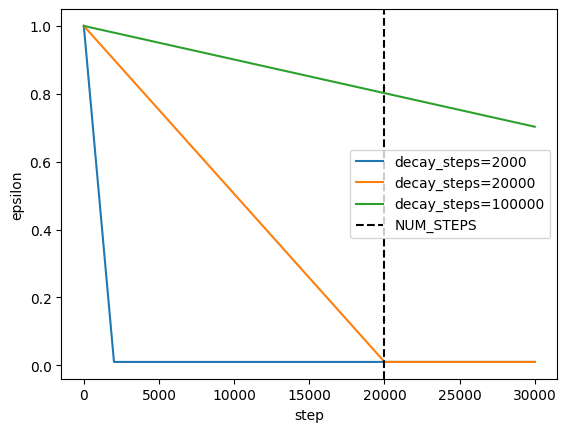

In [5]:
steps = np.arange(0, 30000)
for decay in (2000, 20000, 100000):
    plt.plot(steps, [epsilon_at(s, decay_steps=decay) for s in steps], label=f"decay_steps={decay}")
plt.axvline(NUM_STEPS, color="k", ls="--", label="NUM_STEPS")
plt.xlabel("step")
plt.ylabel("epsilon")
plt.legend()
plt.show()

**Questions**
- At what step does the agent act mostly greedily with `EPSILON_DECAY_STEPS=20000`?
- What happens if the decay is too fast?
- What happens if the training run (`NUM_STEPS`) is shorter than the decay?

*Your answers:*
- 
- 
- 

## Part 3: Hyperparameter experiments
Each pair is assigned **one** hyperparameter. Fill in your prediction *before* running. Use at least 3 values and 2 seeds each; the moving average has a window of 20 episodes.

| Group | Hyperparameter | Values to try | Prediction | Observation |
|---|---|---|---|---|
| A | `LR` | 1e-2, 1e-3, 1e-4 | | |
| B | `GAMMA` | 0.5, 0.9, 0.99 | | |
| C | `EPSILON_DECAY_STEPS` | 2000, 20000, 100000 | | |
| D | `HIDDEN_SIZE` | 8, 32, 128 | | |

> Each run takes time. Reduce `NUM_STEPS` (for example to 10000) if the session is short.

In [ ]:
# TODO: choose your group's hyperparameter and values
PARAM_NAME = "lr"                  # one of: lr, gamma, eps_decay_steps, hidden_size
PARAM_VALUES = [1e-2, 1e-3, 1e-4]
SEEDS = [0, 1]
RUN_STEPS = NUM_STEPS

results = {}
for value in PARAM_VALUES:
    results[value] = []
    for seed in SEEDS:
        _, rewards = train(num_steps=RUN_STEPS, seed=seed, **{PARAM_NAME: value})
        results[value].append(rewards)
        print(f"{PARAM_NAME}={value} seed={seed} episodes={len(rewards)} last20={np.mean(rewards[-20:]):.1f}")

In [ ]:
colors = plt.cm.tab10.colors
plt.figure(figsize=(9, 5))
for c, (value, runs) in zip(colors, results.items()):
    for k, rewards in enumerate(runs):
        plt.plot(moving_average(rewards), color=c, alpha=0.8, label=f"{PARAM_NAME}={value}" if k == 0 else None)
plt.xlabel("episode")
plt.ylabel("moving average return (20)")
plt.title(f"Effect of {PARAM_NAME}")
plt.legend()
plt.show()

*Group findings (one slide: the plot, whether the prediction held, and why):*

- 

## Part 4: Why is naive DQN unstable?
Run the default configuration with 5 different seeds and plot all learning curves together.

In [ ]:
SEEDS_P4 = [0, 1, 2, 3, 4]
curves = []
for seed in SEEDS_P4:
    _, rewards = train(seed=seed)
    curves.append(rewards)
    print(f"seed={seed} episodes={len(rewards)} best20={moving_average(rewards).max():.1f} last20={np.mean(rewards[-20:]):.1f}")

plt.figure(figsize=(9, 5))
for seed, rewards in zip(SEEDS_P4, curves):
    plt.plot(moving_average(rewards), label=f"seed {seed}")
plt.xlabel("episode")
plt.ylabel("moving average return (20)")
plt.title("Naive DQN, default hyperparameters")
plt.legend()
plt.show()

**Guiding questions**
- Why do the curves differ so much between seeds, and why does the reward often rise and then collapse?
- Consecutive transitions are highly correlated. How does that affect SGD with batch size 1?
- The TD target uses the same network that is being updated. What is the "moving target" problem?

*Your answers:*
- 
- 
- 